Environment name: `r_env_corr`

# 0. - Imports and paths

In [53]:
setwd(dir = "/disk2/user/gabgam/the_project/5_integration_and_correlation/")

In [1]:
suppressMessages(suppressWarnings(source("./utils/source_satac.R")))
library(biovizBase)
library(extrafont) # install.packages("extrafont")
library(Matrix)
library(ape)
library(clustree)

Registering fonts with R

Registered S3 method overwritten by 'ape':
  method   from 
  plot.mst spdep


Attaching package: 'ape'


The following object is masked from 'package:dplyr':

    where


The following object is masked from 'package:ggpubr':

    rotate


The following object is masked from 'package:Biostrings':

    complement


Loading required package: ggraph


Attaching package: 'ggraph'


The following object is masked from 'package:sp':

    geometry




Loading the fonts.

In [2]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf 
# or, better, https://fonts.google.com/specimen/DM+Sans
# Import only DMSans-Medium
# font_import(paths = "../fonts/static/", prompt = FALSE, recursive = FALSE, pattern = "DMSans-Medium.ttf") # select just the Medium one
# loadfonts()  # Load registered fonts

# # verify if the font is available:
# fonts()

In [3]:
# # for font in Base R plots
# par(family = "DM Sans Medium")
# plot(1: 2, main = "Title in Custom Font")

In [4]:
PATH_TO_sATAC_DATA_FOLDER <- "../data/spatial_atac/"
PATH_sATAC_PREPROCESSING_OUTPUT <- "output/sATAC_preprocessing/"
PATH_TO_FIGURES <- "figures/sATAC_preprocessing/"

SELECTED_sATAC_SAMPLE <- "220327_C1"

# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
BRCA_PEAK_CALLS <- paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/BRCA_peakCalls.csv")

---
# 1. - Creating the initial sATAC object

## 1.1 - Creating table with paths to all files

In [5]:
# set paths to raw data and metadata
dirs <- list.dirs(paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/"), recursive = F, full.names = F)
table <- list()


# create a table containing paths to raw and meta data (i.e., output from cellranger + spatial info)
for(i in dirs){
  table[[i]] <- list(samples = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/raw_peak_bc_matrix.h5"),
                  singlecell = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/singlecell.csv"),
                  fragments = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/fragments.tsv.gz"),
                  tissue_paths = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.tsv"),
                  spotfiles = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.csv"))
}

infoTable <- do.call("rbind", table) %>% as.data.frame()
#infoTable <- as.data.frame(table, stringsAsFactors = FALSE)


## 1.2 - Creating count Object for peaks

From the Signac [tutorial](https://stuartlab.org/signac/articles/pbmc_vignette):
```r
fragpath <- '10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz'

# Define cells
# If you already have a list of cell barcodes to use you can skip this step
total_counts <- CountFragments(fragpath)
cutoff <- 1000 # Change this number depending on your dataset!
barcodes <- total_counts[total_counts$frequency_count > cutoff, ]$CB

# Create a fragment object
frags <- CreateFragmentObject(path = fragpath, cells = barcodes)

# First call peaks on the dataset
# If you already have a set of peaks you can skip this step
peaks <- CallPeaks(frags)

# Quantify fragments in each peak
counts <- FeatureMatrix(fragments = frags, features = peaks, cells = barcodes)
```


In [6]:
object <- list(md = list(),
               frag = list(),
               counts = list())

# build new matrices with new peak set
# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
# load peaks and create genomicranges object
gr <- read.csv(
  file = BRCA_PEAK_CALLS,
  col.names = c("chr", "start", "end"),
  sep = ";"
) %>% makeGRangesFromDataFrame()

# create fragment objects and count matrices for each section separately
for(i in seq_along(dirs)){
  # folder = paste0(PATH_TO_sATAC_DATA_FOLDER, "combined/")
  folder = strsplit(infoTable$samples[[i]], "raw_peak_bc_matrix.h5") %>% unlist()
  # load metadata
  object$md[[i]] <- read.table(
    file = infoTable$singlecell[[i]],
    stringsAsFactors = FALSE,
    sep = ",",
    header = TRUE,
    row.names = 1
  )[-1, ] # remove the first row (NO_BARCODE)
  
  # create fragment objects
  object$frag[[i]] <- CreateFragmentObject(
    path = infoTable$fragments[[i]],
    cells = rownames(object$md[[i]])
  )
  
  if (file.exists(paste0(folder, "brca_peak_bc_matrix.h5"))) {
    message("File exists.")
    object$counts[[i]] <- Read10X_h5(paste0(folder, "brca_peak_bc_matrix.h5"))
    
  } else {
    
    # make count matrix
    object$counts[[i]] <- FeatureMatrix(
      fragments = object$frag[[i]],
      features = gr,
      cells = rownames(object$md[[i]])
    )
    
    write10xCounts(path = paste0(folder, "brca_peak_bc_matrix.h5"),
                   x = object$counts[[i]],
                   type = "HDF5") # save new count matrix
  }
  
}

Computing hash

File exists.

Computing hash

File exists.

Computing hash

File exists.



## 1.3 - Building the correct tissue list file

In [7]:
# make tissue position files
for(i in seq_along(infoTable$tissue_paths)){
  spotfile <- read.table(infoTable$tissue_paths[[i]], sep = "\t", header = T)
  
  spotfile_tissue <- cbind(
    spotfile$row, #array_row
    spotfile$col, #array_col
    spotfile$x, #pxl_row_in_fullres
    spotfile$y #pxl_col_in_fullres
  ) %>% as.data.frame()
  tissue <- rep(1, nrow(spotfile_tissue))
  spotfile_tissue <- cbind(tissue, spotfile_tissue)
  rownames(spotfile_tissue) <- paste0(spotfile$barcode, "-1")
  
  # save new tissue position file with the correct columns for creating STutility object as .csv files
  write.csv(spotfile_tissue, 
            paste0(strsplit(infoTable$tissue_paths[[i]], "tsv"), "csv"), 
            sep = ",")
  
}

Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"
Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"
Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"


Loading the files just created for each of the sections.

In [8]:
# load spotfiles
tissue_md <- list()
object$mtx <- list()

for(i in seq_along(infoTable$spotfiles)){
  spotfile <- read.csv(infoTable$spotfiles[[i]],
                       col.names = c("barcode", "tissue", "y", "x", "pixel_y", "pixel_x")
  )
  
  # filter count matrix to retain only spots overlaying tissue
  mtx <- object$counts[[i]] # barcodes extracted from here
  mtx <- mtx[,colnames(mtx) %in% spotfile$barcode] 
  
  object$mtx[[i]] <- mtx
  
  #save spot info in a list
  tissue_md[[i]] <- spotfile
}

---
# 2. - Chromatin Assay object and LSI computing
why do they perform normalisation here???

In the Signac [tutorial](https://stuartlab.org/signac/articles/pbmc_vignette) they do:
```r
chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c(":", "-"),
  fragments = "10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz",
  min.cells = 10,
  min.features = 200
)
```

In [9]:
signac_object <- list()

# create signac objects for each section and run normalization and dimensionality reduction
for(i in seq_along(infoTable$spotfiles)){
  
  # creating the Chromatin Assay
  assay <- CreateChromatinAssay(object$mtx[[i]], 
                                fragments = object$frag[[i]])
  
  # creating the signac object and performing an initial filtering 
  signac_object[[i]] <- CreateSeuratObject(assay, 
                                           assay = "peaks", 
                                           meta.data=object$md[[i]],
                                           min.cells = 10,
                                           min.features = 200)

  signac_object[[i]]$section <- rownames(infoTable)[i]
  signac_object[[i]]$sample <- i
  
  # compute LSI
  # signac_object[[i]] <- FindTopFeatures(signac_object[[i]], min.cutoff = 10)
  # signac_object[[i]] <- RunTFIDF(signac_object[[i]])
  # signac_object[[i]] <- RunSVD(signac_object[[i]])
}

# naming the objects in the correct way
names(signac_object) <- rownames(infoTable)
signac_object

Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."


$`220327_C1`
An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data

$`220327_C2`
An object of class Seurat 
215978 features across 2795 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data

$`220327_D2`
An object of class Seurat 
215978 features across 3533 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data


Not normalised with LSI in this case.

The normalisation happens on the `data` object.

## 2.1 - Adding the spatial data to meta

In [10]:
# add spatial data to meta
for(i in seq_along(infoTable$tissue_paths)){
  # tissue_md[[i]]$barcode <- paste0(tissue_md[[i]]$barcode, "_", i)
  tissue_md[[i]]$barcode <- paste0(tissue_md[[i]]$barcode, "_", i)
  rownames(tissue_md[[i]]) <- tissue_md[[i]]$barcode
  signac_object[[i]] <- AddMetaData(signac_object[[i]], tissue_md[[i]])
}

In [11]:
names(signac_object)

[1] "220327_C1" "220327_C2" "220327_D2"

## 2.2 - Adding the images

In [12]:
# Create a list to store Seurat objects, each with its own spatial image
seurat_list <- list()

# Create a metadata table (infoTable) containing file paths for each sample
table <- list()
for(i in names(signac_object)){
  table[[i]] <- c(samples = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/brca_peak_bc_matrix.h5"),
                  spotfiles = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.csv"),
                  imgs = paste0(PATH_TO_sATAC_DATA_FOLDER, "spatial/", i, "_cropped.jpg"))
}

infoTable <- do.call("rbind", table) %>% as.data.frame()

# Iterate over all samples to process them separately
for (i in seq_along(dirs)) {
  sample_name <- dirs[i]
  
  # Read spatial barcode positions
  xy.raw <- setNames(read.csv(file = infoTable$spotfiles[i]), 
                     nm = c("barcode", "tissue", "y", "x", "pixel_y", "pixel_x"))
  xy <- xy.raw[, c("x", "y")]
  
  # Load and scale the corresponding image
  img_path <- infoTable$imgs[i]
  img <- readJPEG(img_path)
  
  sf <- c(ncol(img)/128, nrow(img)/78)
  xy$x <- xy$x * sf[1]
  xy$y <- xy$y * sf[2]
  
  # Create a spot selection table with updated pixel coordinates
  spotfile <- data.frame(xy.raw$barcode, xy.raw$tissue, xy.raw$y, xy.raw$x, round(xy$y), round(xy$x))
  spotfile_path <- paste0(strsplit(infoTable$spotfiles[i], ".csv"), "_positions_list.csv")
  write.table(spotfile, file = spotfile_path, sep = ",", quote = F, row.names = F, col.names = F)
  
  # Update infoTable to reference the new spotfile
  infoTable$spotfiles[i] <- spotfile_path
  
  # Create a Seurat object for each sample
  se <- InputFromTable(infoTable[i, , drop = FALSE], scaleVisium = 1)
  se <- LoadImages(se, time.resolve = FALSE)
  
  # Store the Seurat object with the sample name
  # seurat_list[[sample_name]] <- se
  signac_object[[i]]@tools[["Staffli"]] <- se@tools$Staffli # create STutility object for spatial plots
}


Using spotfiles to remove spots outside of tissue


Warning message:
"Only 1 scaleVisium provided. Using this scalefactor for all samples ... 
"


Loading ../data/spatial_atac/outs/220327_C1/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"



------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  3781  
After filtering the dimensions of the experiment is: [212197 genes, 3538 spots] 
Loading images for 1 samples: 
  Reading ../data/spatial_atac/spatial/220327_C1_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10914x11438 pixels to 400x419 pixels 


...


------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  3390  
After filtering the dimensions of the experiment is: [212588 genes, 2795 spots] 
Loading images for 1 samples: 
  Reading ../data/spatial_atac/spatial/220327_C2_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10913x11438 pixels to 400x419 pixels 
Using spotfiles to remove spots outside of tissue


Warning message:
"Only 1 scaleVisium provided. Using this scalefactor for all samples ... 
"


Loading ../data/spatial_atac/outs/220327_D2/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"



------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  2578  
After filtering the dimensions of the experiment is: [213400 genes, 3533 spots] 
Loading images for 1 samples: 
  Reading ../data/spatial_atac/spatial/220327_D2_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10914x11438 pixels to 400x419 pixels 


---

## 2.3 - Selecting just my sample

In [13]:
# Extract Only `220327_C1`
signac_selected <- signac_object[[SELECTED_sATAC_SAMPLE]]

# Save Processed Object
# saveRDS(signac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, paste0("2", SELECTED_sATAC_SAMPLE, "_signac_object.rds")))
# saveRDS(signac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, paste0("2_", SELECTED_sATAC_SAMPLE, "_selected_signac_object.rds")))

# Print Summary
signac_selected

An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data

In [14]:
signac_selected@tools[["Staffli"]]

An object of class Staffli 
3538 spots across 1 samples. 

Available image representations: 
   raw 

In [15]:
dim(signac_selected)

[1] 215978   3538

---
# 3. - Quality Control

As a part of the preprocesing, first of all, we remove the features that correspond to chromosome scaffolds e.g. (KI270713.1) or other sequences instead of the (22+2) standard chromosomes.

## 3.1 - Keeping only normal chromosomes

In [16]:
peaks.keep <- seqnames(granges(signac_selected)) %in% standardChromosomes(granges(signac_selected))
signac_selected <- signac_selected[as.vector(peaks.keep), ]

## 3.2 - Attaching the correct annotation

We can also add gene annotations to the object for the human genome. This will allow downstream functions to pull the gene annotation information directly from the object.

Multiple patches are released for each genome assembly. When dealing with mapped data, it is advisable to use the annotations from the same assembly patch that was used to perform the mapping.

Usually, you can recover the used reference from the dataset summary; in this case, we will retrieve the information from the spatial ATAC article or from the code itself (where they just say "hg38").\
Thanks to this, we can see that the reference used to perform the mapping was “GRCh38-2020-A”, which corresponds to the Ensembl v98 patch release.

In [17]:
# here there are a lot of warnings about no sequence levels in common
annotations <- suppressWarnings(GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)) #GRCh38.p7, Oct 2016 -> v86
seqlevels(annotations) <- paste0('chr', seqlevels(annotations)) # just like UCSC genome annotations
genome(annotations) <- "hg38"
suppressWarnings(Annotation(signac_selected) <- annotations)

## 3.3 - Computing QC Metrics
We can now compute some QC metrics for the scATAC-seq experiment. We currently suggest the following metrics below to assess data quality. As with scRNA-seq, the expected range of values for these parameters will vary depending on your biological system, cell viability, and other factors.

Remember: Signac extracts the fragment counts per peak for each spot. Then:
1.  `CreateChromatinAssay()` stores the peak x spot count matrix.
2.  `CreateSeuratObject()` automatically computes:

    - `nCount_peaks` = Total number of fragments per spot.
    - `nFeature_peaks` = The number of distinct peaks (open chromatin regions) that contain at least one read in a given spot.

So, we are going to check:
-   Nucleosome banding pattern: The histogram of DNA fragment sizes (determined from the paired-end sequencing reads) should exhibit a strong nucleosome banding pattern corresponding to the length of DNA wrapped around a single nucleosome. We calculate this per single cell, and quantify the approximate ratio of mononucleosomal to nucleosome-free fragments (stored as nucleosome_signal)

-   Transcriptional start site (TSS) enrichment score: The ENCODE project has defined an ATAC-seq targeting score based on the ratio of fragments centered at the TSS to fragments in TSS-flanking regions (see https://www.encodeproject.org/data-standards/terms/). Poor ATAC-seq experiments typically will have a low TSS enrichment score. We can compute this metric for each cell with the `TSSEnrichment()` function, and the results are stored in metadata under the column name TSS.enrichment.

-   Total number of fragments in peaks: A measure of cellular sequencing depth / complexity. Cells with very few reads may need to be excluded due to low sequencing depth. Cells with extremely high levels may represent doublets, nuclei clumps, or other artefacts.

-   Fraction of fragments in peaks: Represents the fraction of all fragments that fall within ATAC-seq peaks. Cells with low values (i.e. <15-20%) often represent low-quality cells or technical artifacts that should be removed. Note that this value can be sensitive to the set of peaks used.

-   Ratio reads in genomic blacklist regions: The ENCODE project has provided a list of [blacklist regions](https://github.com/Boyle-Lab/Blacklist), representing reads which are often associated with artefactual signal. Cells with a high proportion of reads mapping to these areas (compared to reads mapping to peaks) often represent technical artifacts and should be removed. ENCODE blacklist regions for human (hg19 and hg38), mouse (mm9 and mm10), Drosophila (dm3 and dm6), and C. elegans (ce10 and ce11) are included in the Signac package. The `FractionCountsInRegion()` function can be used to calculate the fraction of all counts within a given set of regions per cell. We can use this function and the blacklist regions to find the fraction of blacklist counts per cell.

Note that the last three metrics can be obtained from the output of CellRanger (which is stored in the object metadata).

In [18]:
# print(names(signac_selected@meta.data))

In [19]:
# compute nucleosome signal score per cell
signac_selected <- NucleosomeSignal(object = signac_selected)

# compute TSS enrichment score per cell
signac_selected <- TSSEnrichment(object = signac_selected, fast = FALSE)

# add fraction of reads in peaks
signac_selected$fract_reads_in_peaks <- signac_selected$peak_region_fragments / signac_selected$passed_filters * 100

# Fraction of Reads in Peaks (FRiP Score)
signac_selected$FRiP <- signac_selected$nFeature_peaks / signac_selected$nCount_peaks
# Mitochondrial Read Percentage
signac_selected$mitoRatio <- signac_selected$mitochondrial / signac_selected$total

# add blacklist ratio
signac_selected$blacklist_ratio <- FractionCountsInRegion(
  object = signac_selected, 
  assay = 'peaks',
  regions = blacklist_hg38_unified
)

Extracting TSS positions

Finding + strand cut sites

Finding - strand cut sites

Computing mean insertion frequency in flanking regions

Normalizing TSS score



The relationship between variables stored in the object metadata can be visualized using the `DensityScatter()` function. This can also be used to quickly find suitable cutoff values for different QC metrics by setting `quantiles=TRUE`:

### 3.3.1 - Density plot

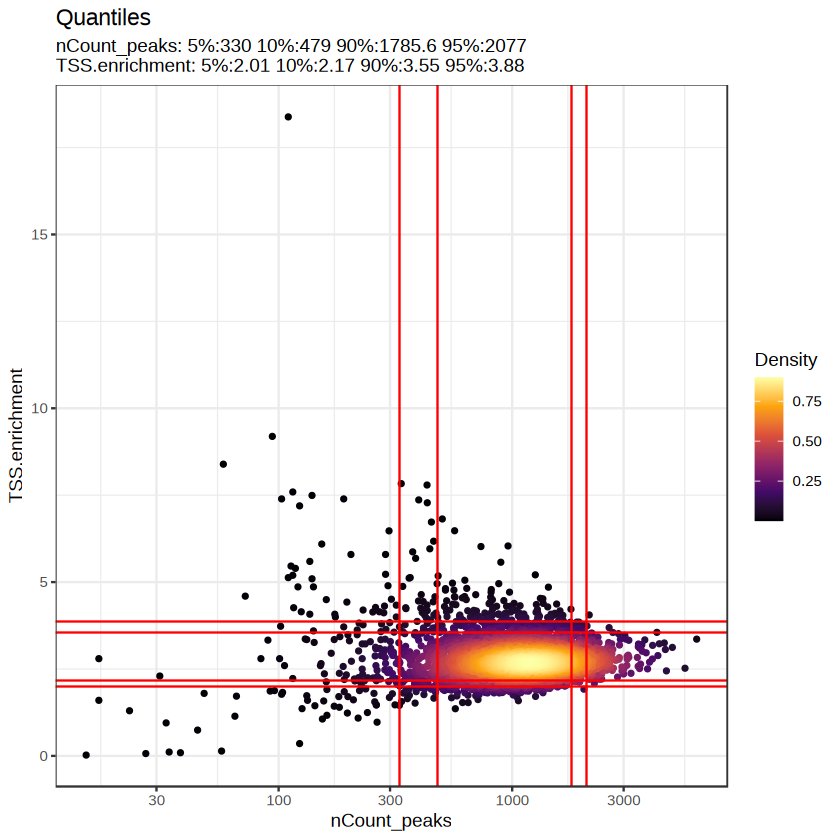

In [20]:
DensityScatter(signac_selected, x = 'nCount_peaks', y = 'TSS.enrichment', log_x = TRUE, quantiles = TRUE)

### 3.3.2 - TSS Enrichment
**TSS Enrichment Score**

-   Measures accessibility at transcription start sites (TSS).
-   Similar to bulk/single-cell ATAC, high scores indicate open chromatin around TSS.
-   Good threshold: TSS enrichment > 8-10 in snATAC-seq, but might be lower in spatial ATAC.

`geom_smooth()` using formula = 'y ~ x'


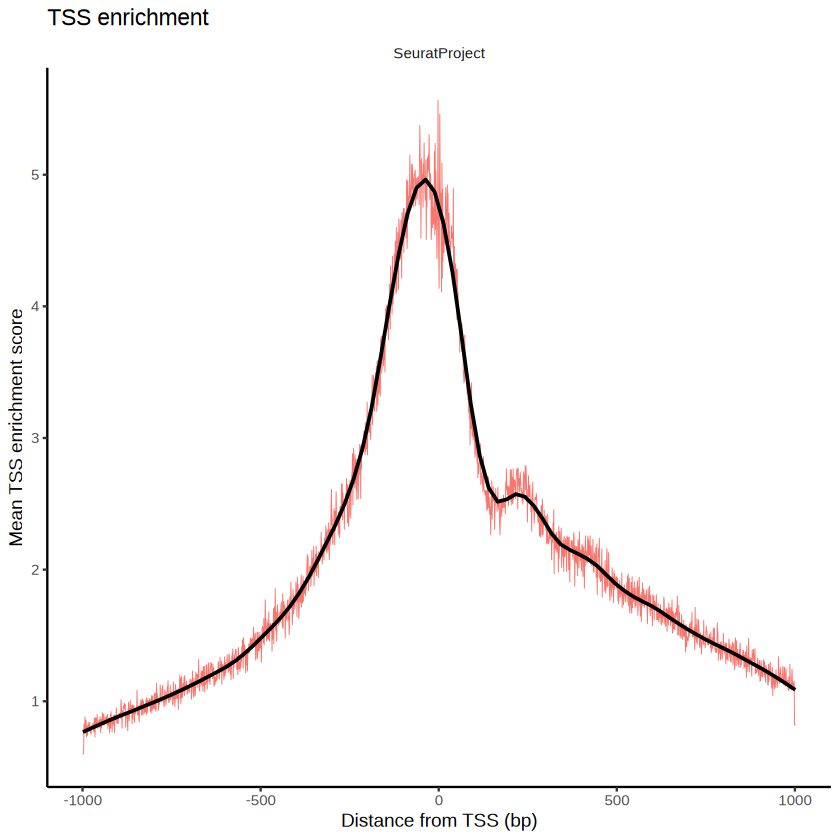

In [21]:
p2 <- TSSPlot(signac_selected)
p2 + geom_smooth(method = "loess", span = 0.15, se = FALSE, color = "black", linewidth = 0.8)

We can also look at the fragment length periodicity for all the cells, and group by cells with high or low nucleosomal signal strength. You can see that cells that are outliers for the mononucleosomal / nucleosome-free ratio (based on the plots above) have different nucleosomal banding patterns. The remaining cells exhibit a pattern that is typical for a successful ATAC-seq experiment.

### 3.3.3 - Fragments length

Warning message:
"Removed 50 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


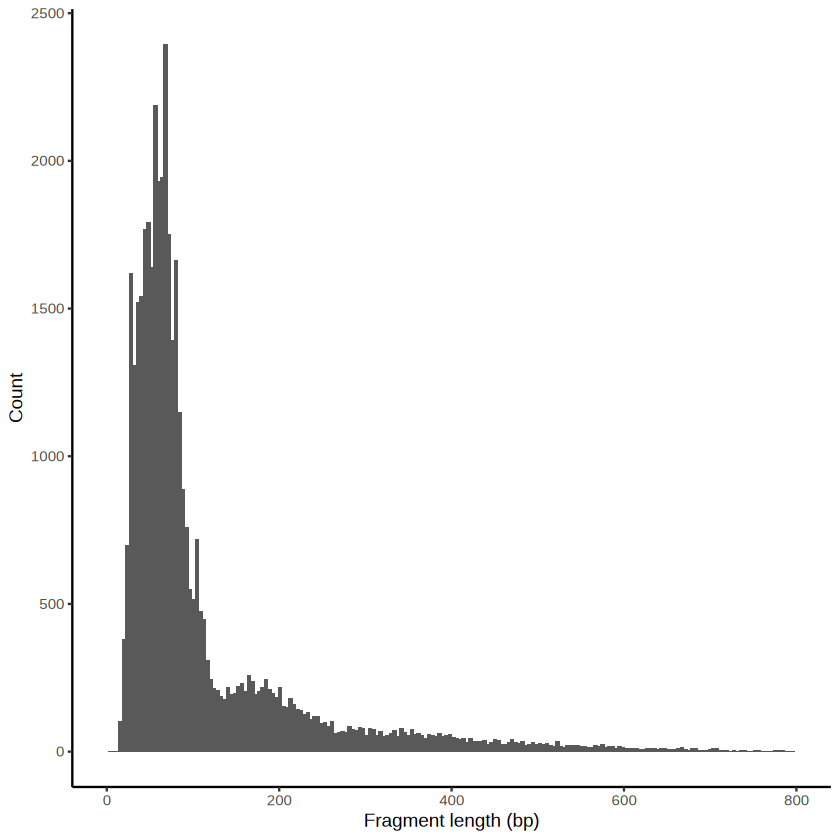

In [22]:
FragmentHistogram(object = signac_selected)

### 3.3.4 - FRiP score
Fraction of Reads in Peaks (FRiP Score)
-   Measures signal-to-noise ratio by computing the fraction of fragments that fall within called peaks.
-   High FRiP (>0.2-0.3) indicates good quality; low FRiP (<0.1) suggests background noise.

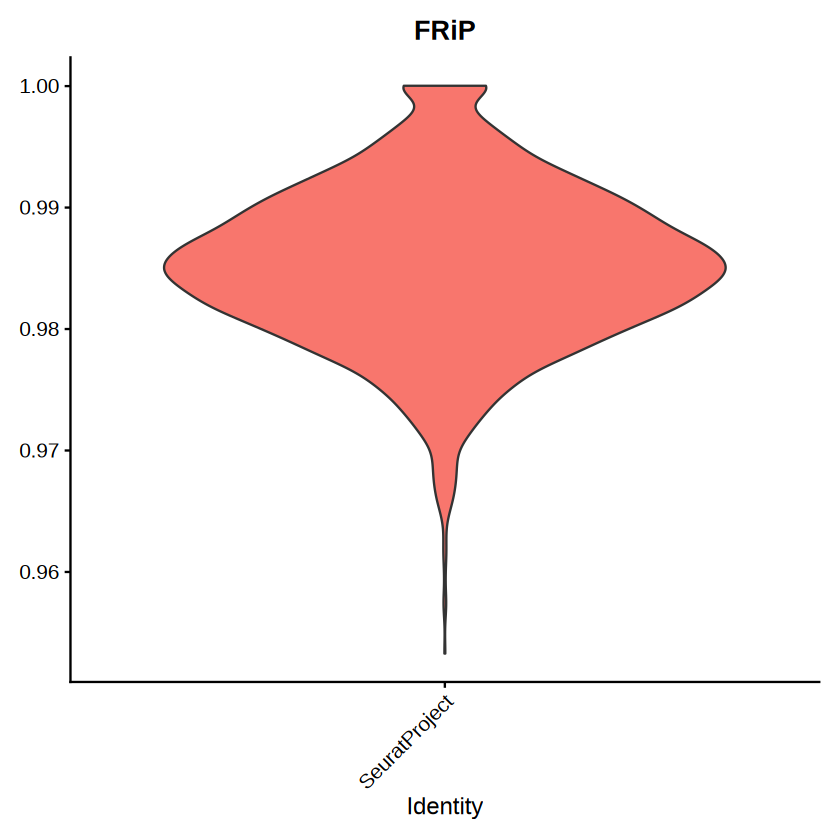

In [23]:
VlnPlot(
  object = signac_selected,
  features = c('FRiP'),
  ncol = 1,
  pt.size = 0,
  group.by = "orig.ident"
  ) + NoLegend()

### 3.3.5 - Total fragments per Spot
-   Similar to fragments per cell in snATAC-seq, this measures sequencing depth per spatial location.
-   Expected distribution: A log-normal or heavy-tailed distribution.
-   Possible threshold: Spots with very low fragments (<1000) might be discarded.

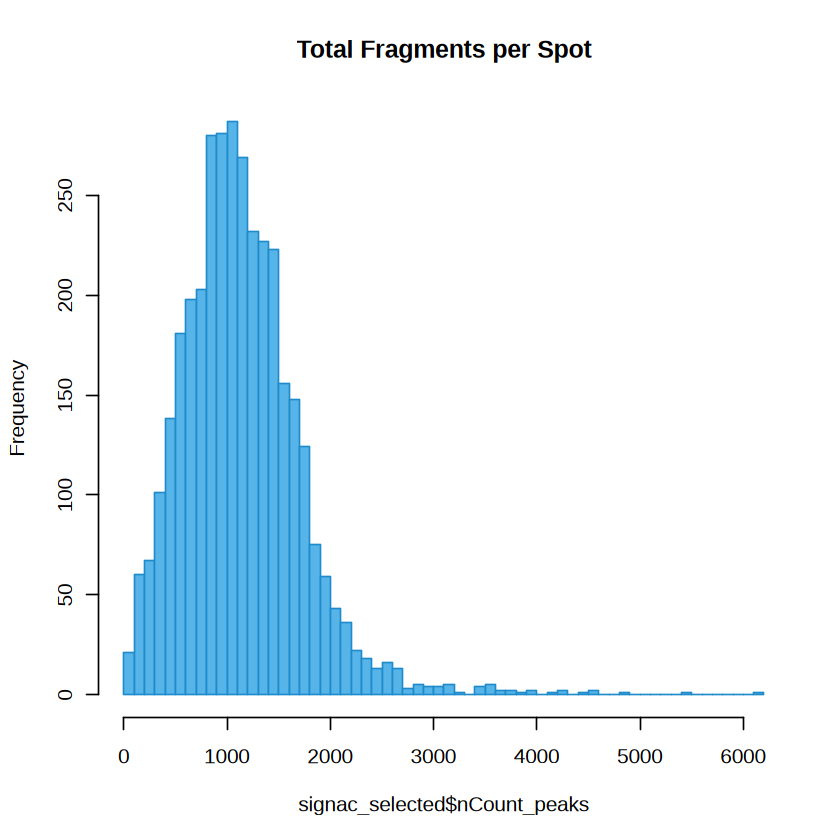

In [24]:
hist(signac_selected$nCount_peaks, breaks = 50, main = "Total Fragments per Spot", col = colors_okate[4], border = "#1f8bca")


### 3.3.5 - Other metrics

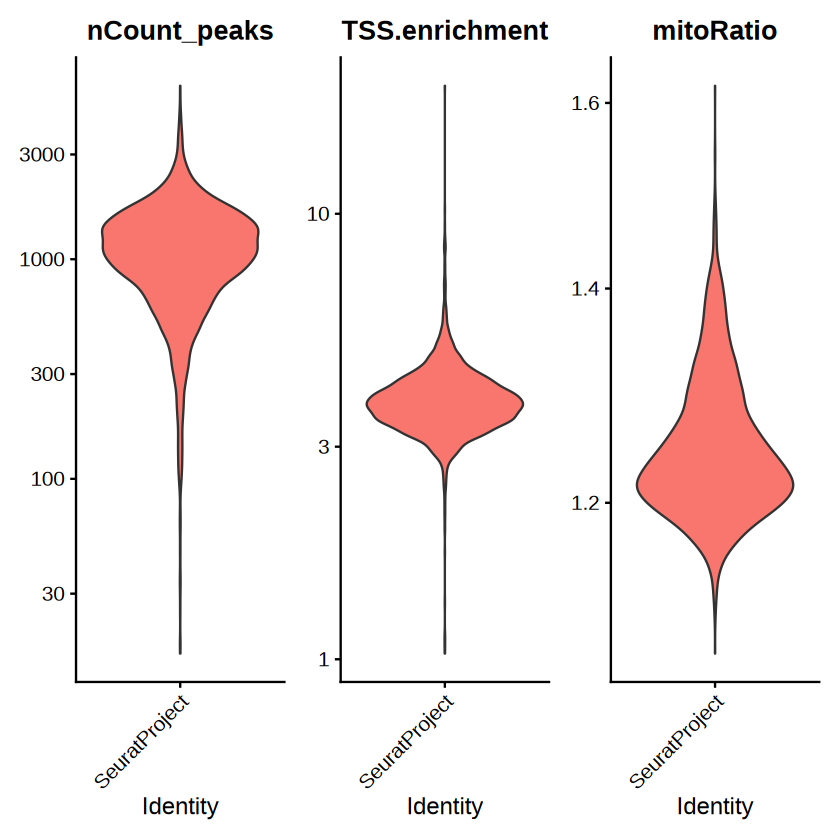

In [25]:
VlnPlot(signac_selected, features = c('nCount_peaks', 'TSS.enrichment', 'mitoRatio'), 
        ncol = 3, pt.size = 0, log = TRUE, group.by = "orig.ident")


---
# 4. - Computing LSI normalisation and clustering
I don't think that I should normalise once again.

In [26]:
#preprocess raw data
signac_selected <- signac_selected %>% 
  RunTFIDF() %>%
  FindTopFeatures(min.cutoff = 'q0') %>%
  RunSVD()

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
"Some features contain 0 total counts"


Running SVD

Scaling cell embeddings



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"


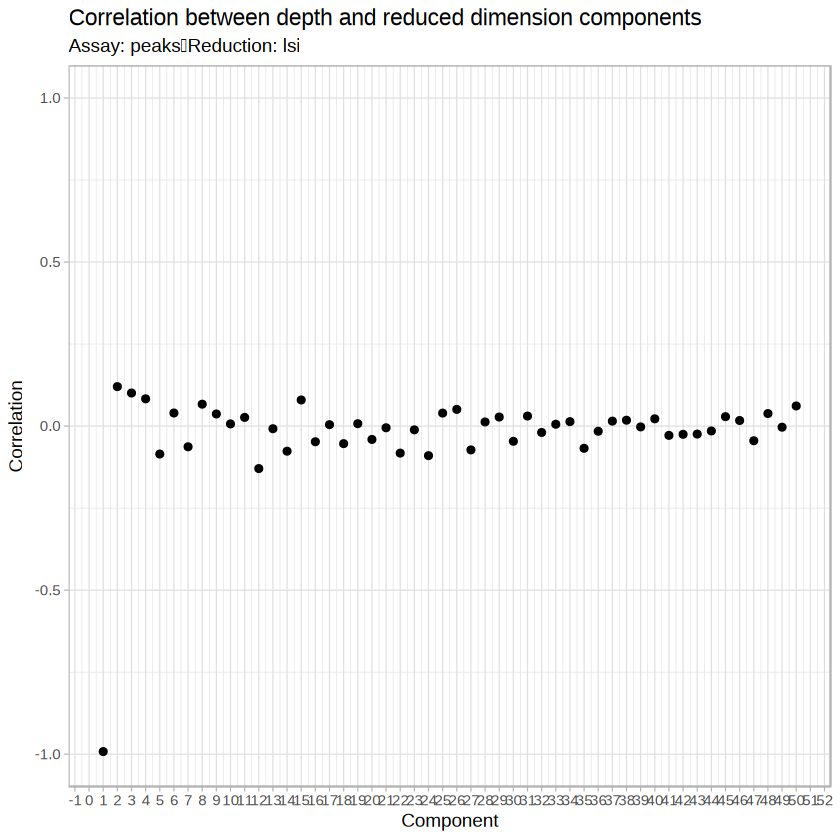

In [27]:
DepthCor(signac_selected, n = 50)

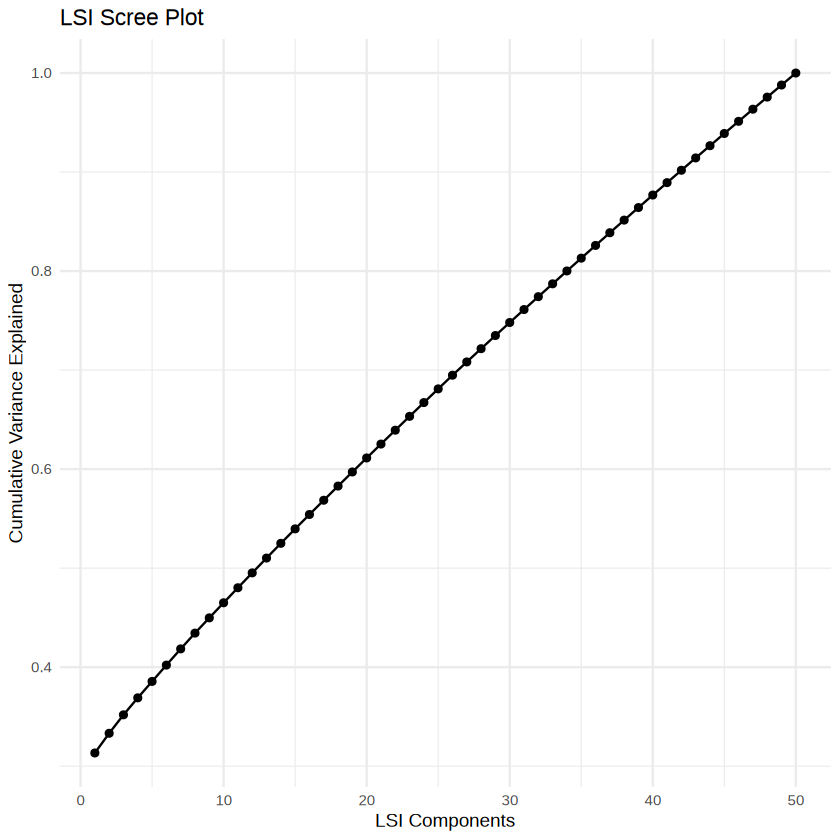

In [28]:
lsi_singular_values <- signac_selected@reductions$lsi@stdev

variance_explained <- (lsi_singular_values^2) / sum(lsi_singular_values^2)
cumulative_variance <- cumsum(variance_explained)

ggplot(data.frame(PC = 1:length(cumulative_variance), Variance = cumulative_variance), aes(x = PC, y = Variance)) +
  geom_point() + geom_line() +
  xlab("LSI Components") + ylab("Cumulative Variance Explained") +
  ggtitle("LSI Scree Plot") +
  theme_minimal()

Here we see there is a very strong correlation between the first LSI component and the total number of counts for the cell. We will perform downstream steps without this component as we don’t want to group cells together based on their total sequencing depth, but rather by their patterns of accessibility at cell-type-specific peaks.

And then they choose 7 components, while in the tutorial, they go for `2:30`.

In [29]:
signac_selected <- signac_selected %>%
  RunUMAP(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindNeighbors(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindClusters(algorithm = 3, resolution = seq(from = 0.0, to = 1.2, by = 0.1), verbose = FALSE)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


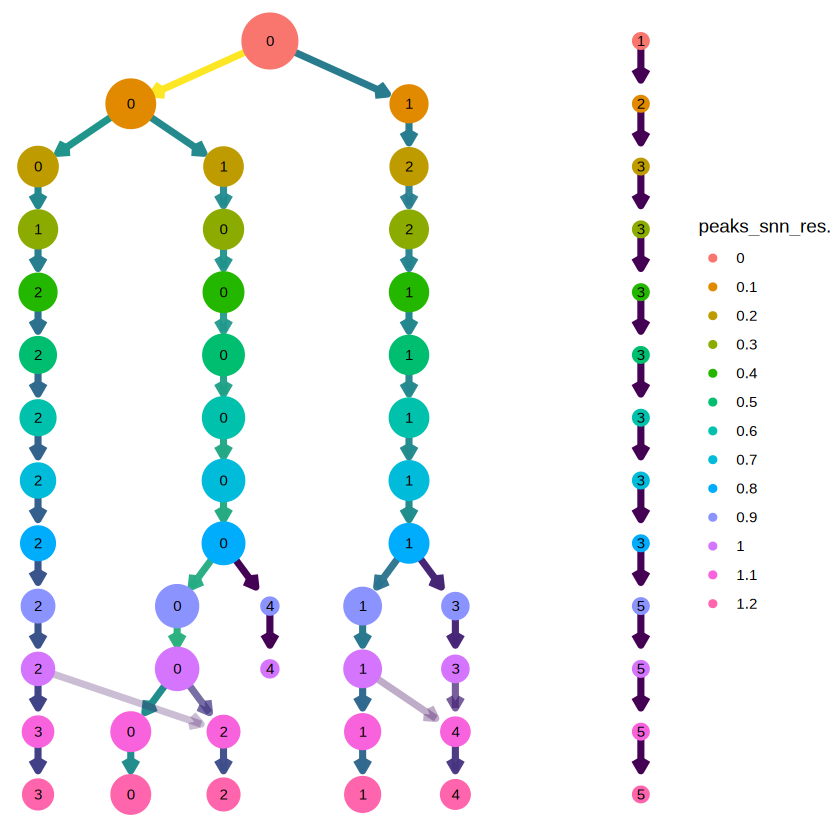

In [30]:
  clustree(signac_selected, prefix = "peaks_snn_res.", node_colour_agglomerate = FALSE) + 
    guides(edge_colour = "none", edge_alpha = "none", size = "none")

## 4.1 - Plotting by clusters

Choosing the final resolution to go for.

In [31]:
FINAL_RESOLUTION_PEAKS <- 0.5
CLUSTERING_NAME_PEAKS <- paste0("peaks_snn_res_", FINAL_RESOLUTION_PEAKS)

signac_selected <- signac_selected %>%
  RunUMAP(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindNeighbors(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindClusters(algorithm = 3, resolution = FINAL_RESOLUTION_PEAKS, verbose = FALSE, cluster.name = CLUSTERING_NAME_PEAKS)

table(signac_selected[[CLUSTERING_NAME_PEAKS]])

peaks_snn_res_0.5
   0    1    2    3 
1433 1173  930    2 

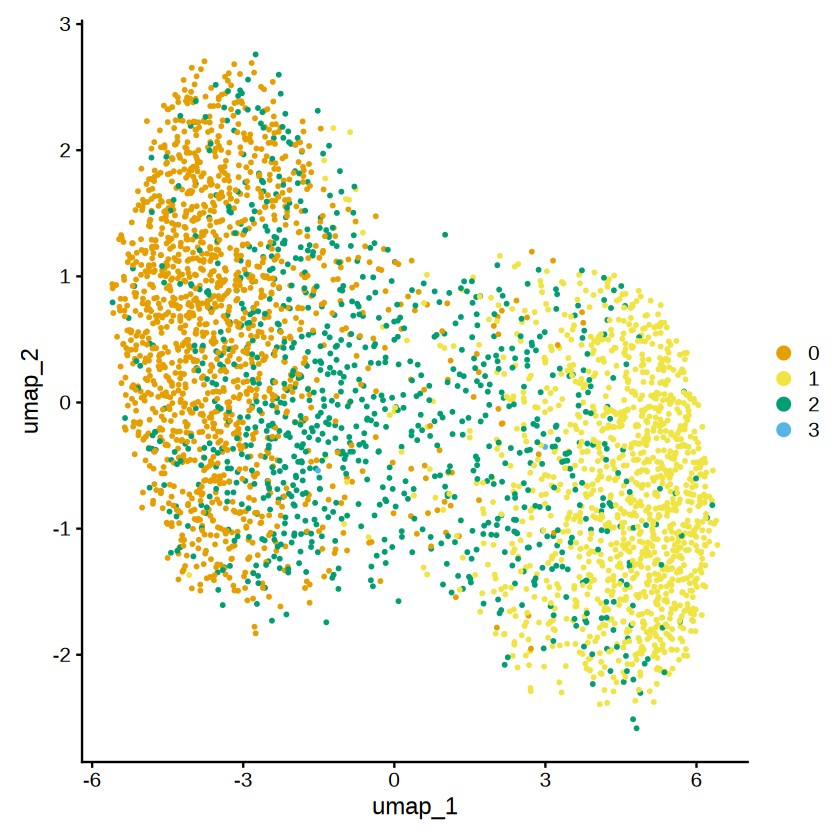

In [32]:
DimPlot(object = signac_selected, reduction = "umap", cols=colors_okate, label = FALSE)# + NoLegend()

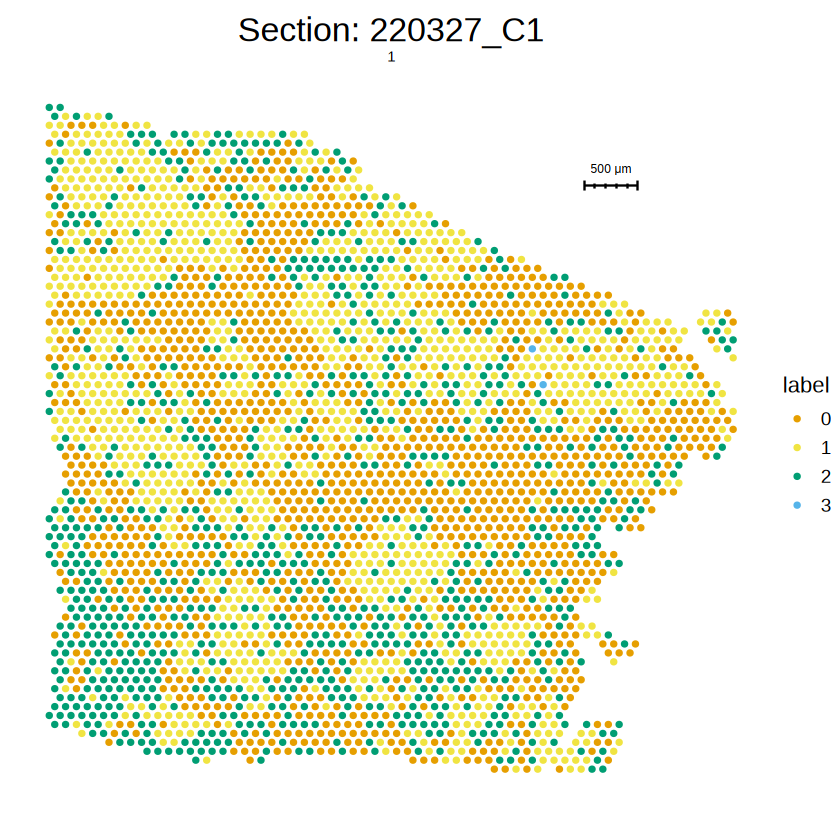

In [33]:
for (sec in unique(signac_selected$section)) {
    p <- ST.FeaturePlot(subset(signac_selected, section == sec), 
                        features = "seurat_clusters", 
                        cols = colors_okate,
                        pt.size = 1.8) +
         ggtitle(paste("Section:", sec)) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
    plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

## 4.2 - Plotting by chromatin accessibility

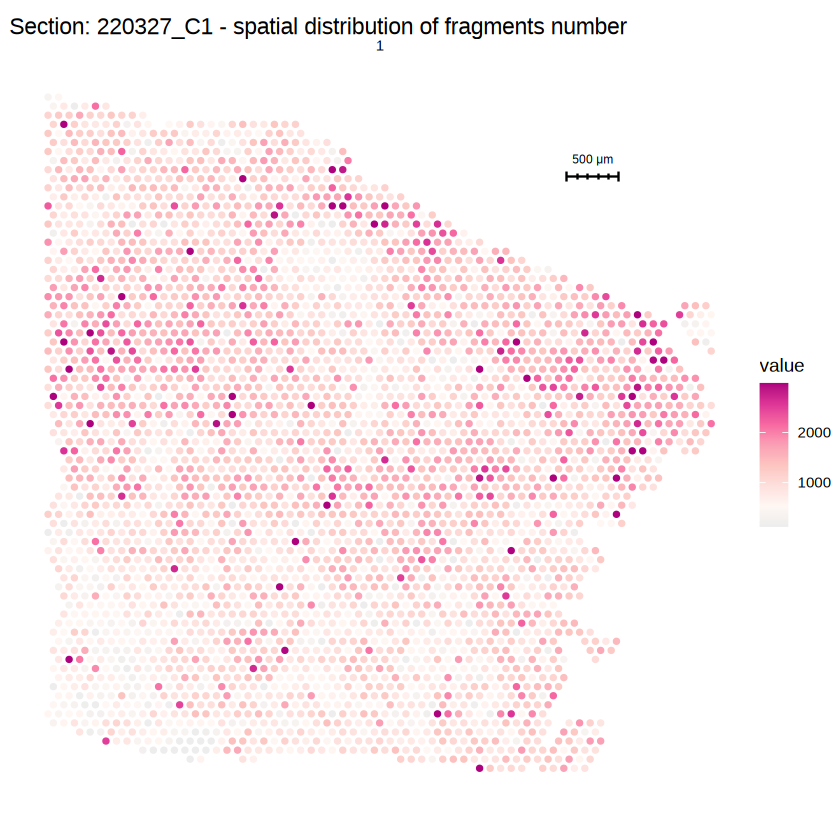

In [34]:
DefaultAssay(signac_selected) <- 'peaks'

ST.FeaturePlot(signac_selected, 
                'nCount_peaks', 
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- spatial distribution of fragments number"))

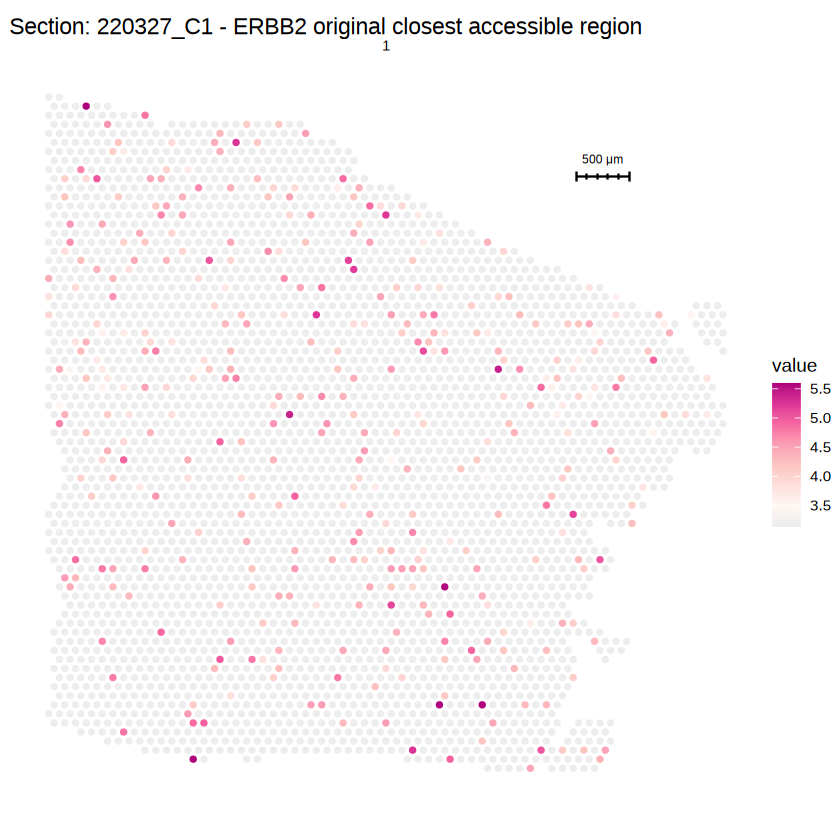

In [35]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)

ST.FeaturePlot(signac_selected, 
                'chr17-39699726-39700227', 
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 original closest accessible region"))

    # plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


## 4.3 - Saving the normalised output

in the original code they use `data`, which is the normalised matrix.

In [36]:
# # #save normalised data matrix for denoising
# write.csv(signac_selected@assays$peaks@data,
#         paste0("./output/sATAC_preprocessing/data_signac_", SELECTED_sATAC_SAMPLE, "_selected_brca_q0_peak_bc_matrix2.csv"))
# write.csv(signac_selected@assays$peaks@counts,
#         paste0("./output/sATAC_preprocessing/counts_signac_", SELECTED_sATAC_SAMPLE, "_selected_brca_q0_peak_bc_matrix2.csv"))

Save the R session as `.RDS` file.

In [37]:
# saveRDS(signac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "1_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca.rds"))

---
# 5. - DCA - Peaks denoiser

On terminal, in a Python environment with TensorFlow and the DCA package installed, such as `dca_mamba_37` run:\
  - for prenormalised data:
```sh
nohup dca output/sATAC_preprocessing/data_signac_<SECTION_NAME>_selected_brca_q0_peak_bc_matrix2.csv output/sATAC_preprocessing/dated_dca_<SECTION_NAME>_peaks_q0_brca --threads 6 --nosizefactors --nonorminput --nologinput --saveweights --nocheckcounts > nohup_for_dca_data.out &
```

---

In [38]:
# load denoised matrices and save objects - separately for peaks and gene activity due to large size
# peaks
# denoised_counts <- read.table(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "dated_dca_", SELECTED_sATAC_SAMPLE, "_peaks_q0_brca/mean.tsv"), row.names = 1)# %>% 
#   # as.matrix()
# denoised_counts <- read.table(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "counted_dca_", SELECTED_sATAC_SAMPLE, "_peaks_q0_brca/mean.tsv"), row.names = 1)# %>% 
denoised_counts <- read.table(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "counted_dca_", SELECTED_sATAC_SAMPLE, "_peaks_q0_brca2/mean.tsv"), row.names = 1)# %>% 
  # as.matrix()
colnames(denoised_counts) <- sub("\\.", "-", colnames(denoised_counts))

In [39]:
# Convert to sparse matrix (dgCMatrix format)
denoised_counts_sparse <- as(as.matrix(denoised_counts), "dgCMatrix")
head(denoised_counts_sparse)

  [[ suppressing 3538 column names 'AAACAAGGGATCAAAT-1', 'AAACAGCAGTCTGCTA-1', 'AAACATTCGGGATTCT-1' ... ]]



6 x 3538 sparse Matrix of class "dgCMatrix"
                                                                          
chr1-975451-975952   0.012866 0.006632 0.014403 0.017814 0.000442 0.001995
chr1-1014228-1014729 0.011148 0.007749 0.013367 0.016570 0.000256 0.001285
chr1-1290080-1290581 0.006085 0.003159 0.004540 0.005335 0.000924 0.003040
chr1-1291099-1291600 0.003177 0.001801 0.002813 0.003426 0.001241 0.002907
chr1-1291742-1292243 0.004144 0.004377 0.003775 0.006259 0.001239 0.002702
chr1-1327977-1328478 0.003305 0.002546 0.003808 0.005865 0.000339 0.001288
                                                                          
chr1-975451-975952   0.008259 0.008721 0.004433 0.002947 0.005347 0.009640
chr1-1014228-1014729 0.007875 0.005926 0.002768 0.002219 0.005557 0.007591
chr1-1290080-1290581 0.004511 0.008200 0.005022 0.003320 0.002673 0.005265
chr1-1291099-1291600 0.002226 0.004089 0.003928 0.003268 0.002077 0.002355
chr1-1291742-1292243 0.003230 0.004063 0.003035 0.003919

In [40]:
DefaultAssay(signac_selected) <- "peaks"
signac_selected[["dca"]] <- NULL

Warning message:
"Cannot find cell-level meta data named  dca"


In [41]:
dim(denoised_counts_sparse)

[1] 212197   3538

In [42]:
# print(length(setdiff(rownames(signac_selected@assays$dca@data), rownames(signac_selected@assays$peaks@data))))
# # should be empty
# print(length(setdiff(rownames(signac_selected@assays$peaks@data), rownames(signac_selected@assays$dca@data))))
# # there should be differences

# dim(signac_selected[["dca"]]@meta.features)
# dim(signac_selected[["dca"]]@data)
# length(signac_selected[["dca"]]@var.features)

# extra_features <- setdiff(rownames(signac_selected[["dca"]]@meta.features),
#                           rownames(signac_selected[["dca"]]@data))

# length(extra_features) # should print 0
# print(extra_features[1:10]) # should print just NAs

Double checking the filtering

In [43]:
print(DefaultAssay(signac_selected))

[1] "peaks"


## Compare DCA clustering
clustering between DCA and peaks
no need for harmony integration as the sections come from the same sample

In [44]:
signac_selected[["dca"]] <- signac_selected[["peaks"]]
signac_selected@assays$dca@counts <- denoised_counts_sparse
# signac_selected@assays$dca@data <- denoised_counts_sparse


Warning message:
"Key 'peaks_' taken, using 'dca_' instead"


In [45]:
# #  filtering in counts
# signac_selected@assays$dca@counts <- signac_selected@assays$dca@counts[rownames(signac_selected@assays$dca@counts) %in%
#                                                            rownames(signac_selected@assays$dca@data),]
# # filtering in var.features
# signac_selected@assays$dca@var.features <- signac_selected@assays$dca@var.features[signac_selected@assays$dca@var.features %in%
#                                                                        rownames(signac_selected@assays$dca@data)]
# # filtering in meta.features
# signac_selected@assays$dca@meta.features <- signac_selected@assays$dca@meta.features[rownames(signac_selected@assays$dca@meta.features) %in% 
#                                                                         rownames(signac_selected@assays$dca@data), , drop = FALSE]

In [46]:
signac_selected@assays$dca@data <- signac_selected@assays$dca@data[rownames(signac_selected@assays$dca@data) %in%
                                                           rownames(signac_selected@assays$dca@counts),]
signac_selected@assays$dca@var.features <- signac_selected@assays$dca@var.features[signac_selected@assays$dca@var.features %in%
                                                                       rownames(signac_selected@assays$dca@counts)]
signac_selected@assays$dca@meta.features <- signac_selected@assays$dca@meta.features[rownames(signac_selected@assays$dca@meta.features) %in% 
                                                                        rownames(signac_selected@assays$dca@counts), , drop = FALSE]
# filter to retain same spots and features


In [47]:
DefaultAssay(signac_selected) <- "dca"

signac_selected <- signac_selected %>%
  RunTFIDF(verbose = FALSE) %>%
  FindTopFeatures(min.cutoff = 'q0') %>%
  RunSVD()

Running SVD

Scaling cell embeddings



Adding the metadata slot for the following plot.

In [48]:
signac_selected <- AddMetaData(signac_selected, 
                               metadata = Matrix::colSums(signac_selected@assays$dca@counts), 
                               col.name = "nCount_dca")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"


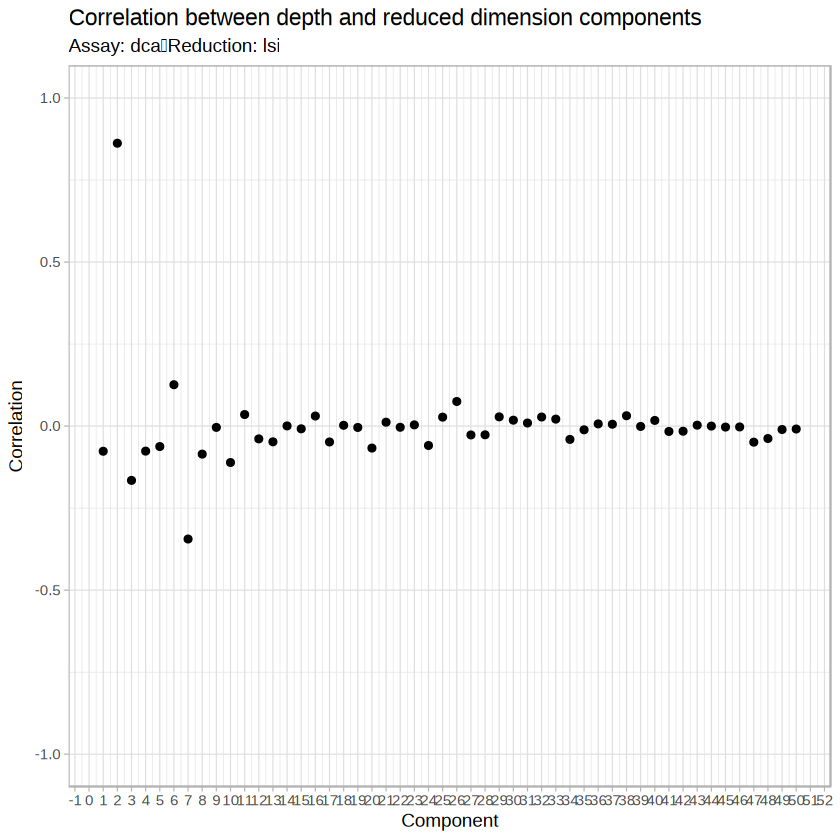

In [49]:
DepthCor(signac_selected, n = 50)

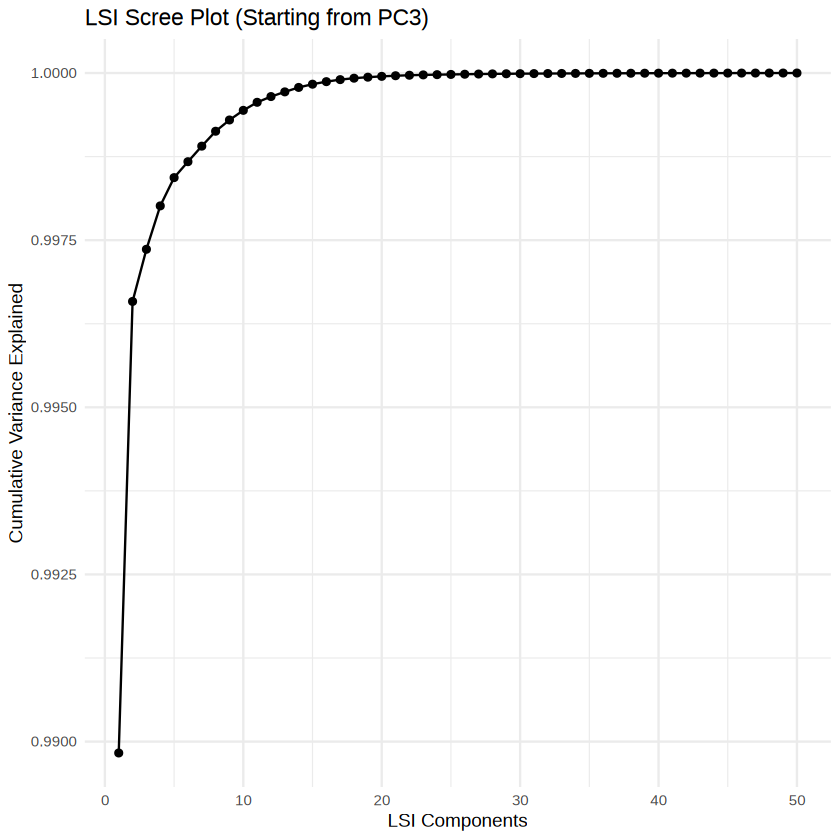

In [50]:
# Compute LSI variance explained
lsi_singular_values <- signac_selected@reductions$lsi@stdev
variance_explained <- (lsi_singular_values^2) / sum(lsi_singular_values^2)
cumulative_variance <- cumsum(variance_explained)

# Create a data frame and filter out the first two components
df <- data.frame(PC = 1:length(cumulative_variance), Variance = cumulative_variance)
# df <- df[df$PC >= 3, ]  # Keep only components from the third onwards

# Plot
ggplot(df, aes(x = PC, y = Variance)) +
  geom_point() + geom_line() +
  xlab("LSI Components") + ylab("Cumulative Variance Explained") +
  ggtitle("LSI Scree Plot (Starting from PC3)") +
  theme_minimal()


## 4.1 - Clustree on denoised peaks

In [51]:
DefaultAssay(signac_selected) <- "dca"

signac_selected <- signac_selected %>%
  RunUMAP(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindNeighbors(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindClusters(algorithm = 3, resolution = seq(from = 0.0, to = 2, by = 0.1), verbose = FALSE)

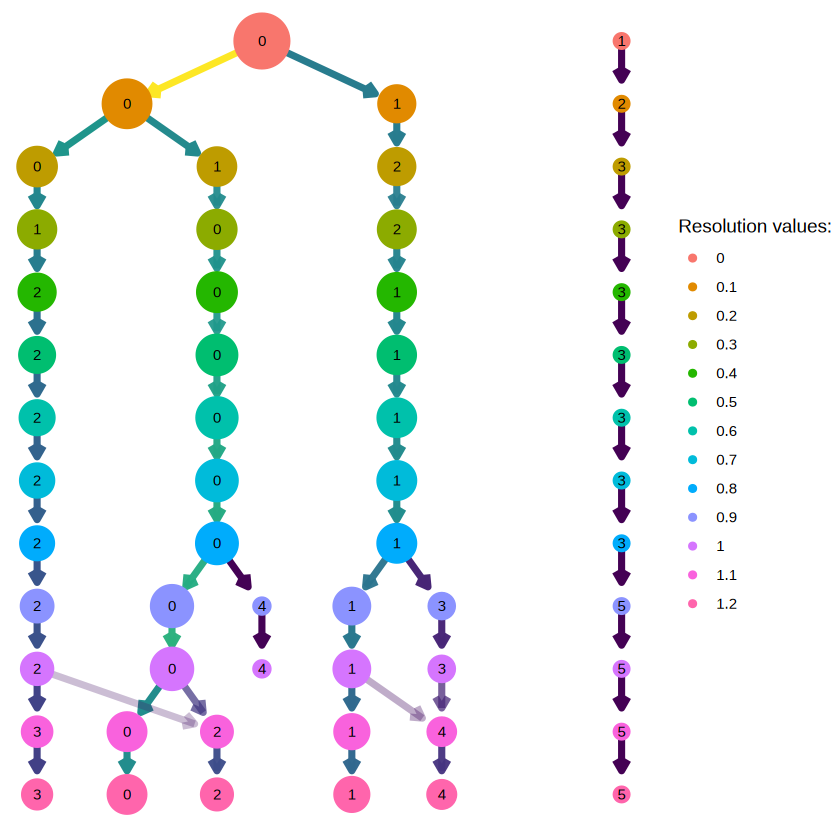

In [52]:
clustree(signac_selected, prefix = "peaks_snn_res.", node_colour_agglomerate = FALSE) + 
    guides(edge_colour = "none", edge_alpha = "none", size = "none") +
    labs(colour = "Resolution values:")

Choosing the final resolution to go for.

In [ ]:
FINAL_RESOLUTION_DENOISED_PEAKS <- 0.4
CLUSTERING_NAME_DENOISED_PEAKS <- paste0("denoised_peaks_snn_res_", FINAL_RESOLUTION_DENOISED_PEAKS)

signac_selected <- signac_selected %>%
  RunUMAP(reduction = "lsi", dims = 3:20, verbose = FALSE) %>%
  FindNeighbors(reduction = "lsi", dims = 3:20, verbose = FALSE) %>%
  FindClusters(resolution = FINAL_RESOLUTION_DENOISED_PEAKS, verbose = FALSE, cluster.name = CLUSTERING_NAME_DENOISED_PEAKS) 

table(signac_selected[[CLUSTERING_NAME_DENOISED_PEAKS]])

In [93]:
# # the first two are identical
# table(signac_selected$peaks_snn_res.0.5)
# table(signac_selected$seurat_clusters)
# table(signac_selected$seurat_clusters_dca_1)
# table(signac_selected$dca_1_snn_res.0.5)

In [94]:
message("FINISHED DCA CLUSTERING!")
# rm(denoised_counts)
# saveRDS(signac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "2_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_n_clustered_brca_denoised_peaks.rds"))

FINISHED DCA CLUSTERING!



Still don't know why I have to do this, it's literally the same object.

  - `FeatureMatrix` → Construct a feature x cell matrix from a genomic fragments file.
  - `write10xCounts` → `rdrr` package function → Create a directory containing the count matrix and cell/gene annotation from a sparse matrix of UMI counts, in the format produced by the CellRanger  software suite. 
  - `GeneActivity` → Compute counts per cell in gene body and promoter region.
  - `seqlevelsStyle` → The `seqlevelsStyle` getter and setter can be used to get the current seqlevels style of an object and to rename its seqlevels according to a given style. 
  - `FindAllMarkers` → `Seurat` package function → Finds markers (differentially expressed genes) for each of the identity classes in a dataset (peaks in our case).
  - `RegionStats` → Compute the GC content, region lengths, and dinucleotide base frequencies for regions in the assay and add to the feature metadata.
  - `LinkPeaks` → Find peaks that are correlated with the expression of nearby genes. For each gene, this function computes the correlation coefficient between the gene expression and accessibility of each peak within a given distance from the gene TSS, and computes an expected correlation coefficient for each peak given the GC content, accessibility, and length of the peak. The expected coefficient values for the peak are then used to compute a z-score and p-value.

adapted cluster comparison for just my section

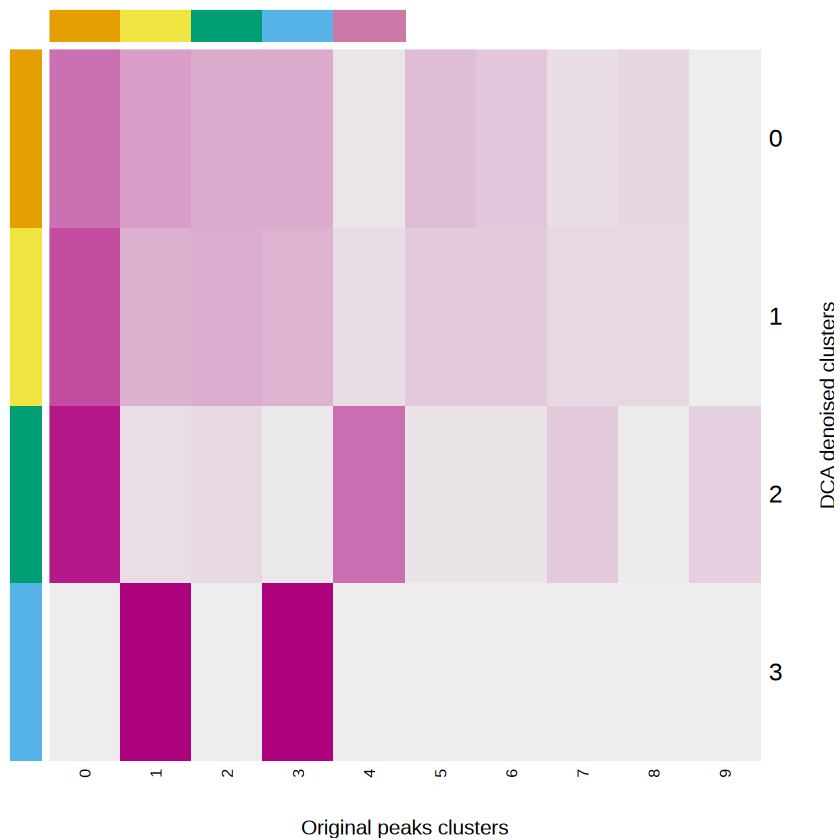

In [96]:
# Check the proportion of spots assigned to each cluster when using denoised vs original data
prop <- prop.table(table(signac_selected$peaks_snn_res.0.5, signac_selected$seurat_clusters_dca), 1)*100

# Ensure colors match the number of clusters
row_colors <- rev(colors_okate[1 : nrow(prop)])
col_colors <- colors_okate[1 : ncol(prop)]

heatmap(prop[order(nrow(prop):1),], 
        Colv = NA, Rowv = NA, scale="none", 
        xlab="Original peaks clusters", ylab="DCA denoised clusters", 
        col = hm_colors, 
        RowSideColors = row_colors, 
        ColSideColors = col_colors)

In [97]:
DefaultAssay(signac_selected) <- "dca"

## 4.1 - Plotting by clusters

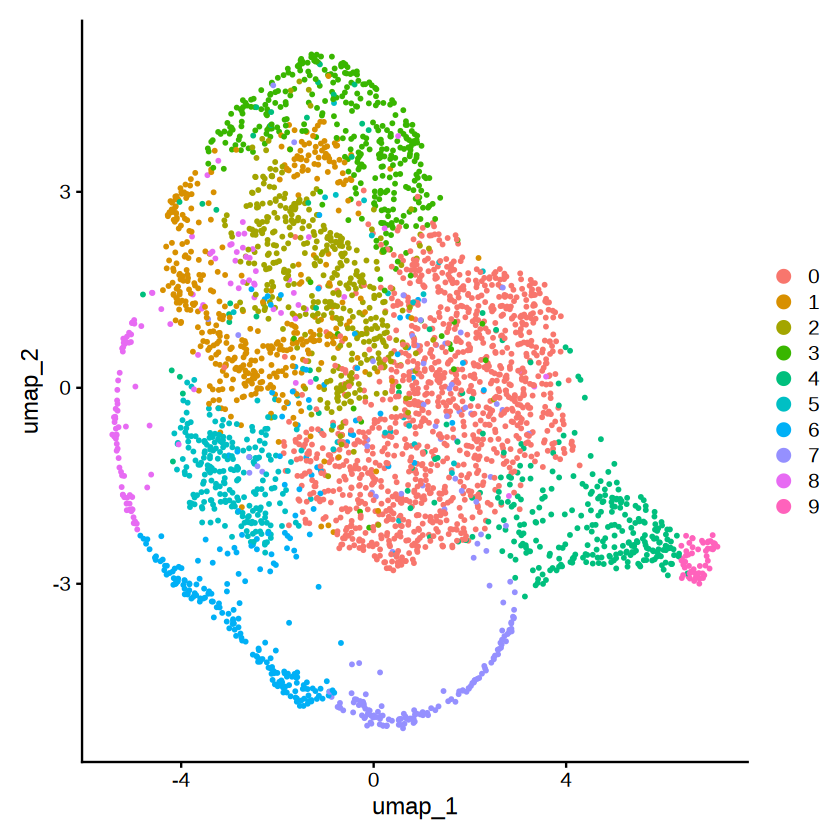

In [98]:
DimPlot(object = signac_selected, reduction = "umap", 
        # cols = colors_okate, 
        # cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"),
        label = FALSE)# + NoLegend()

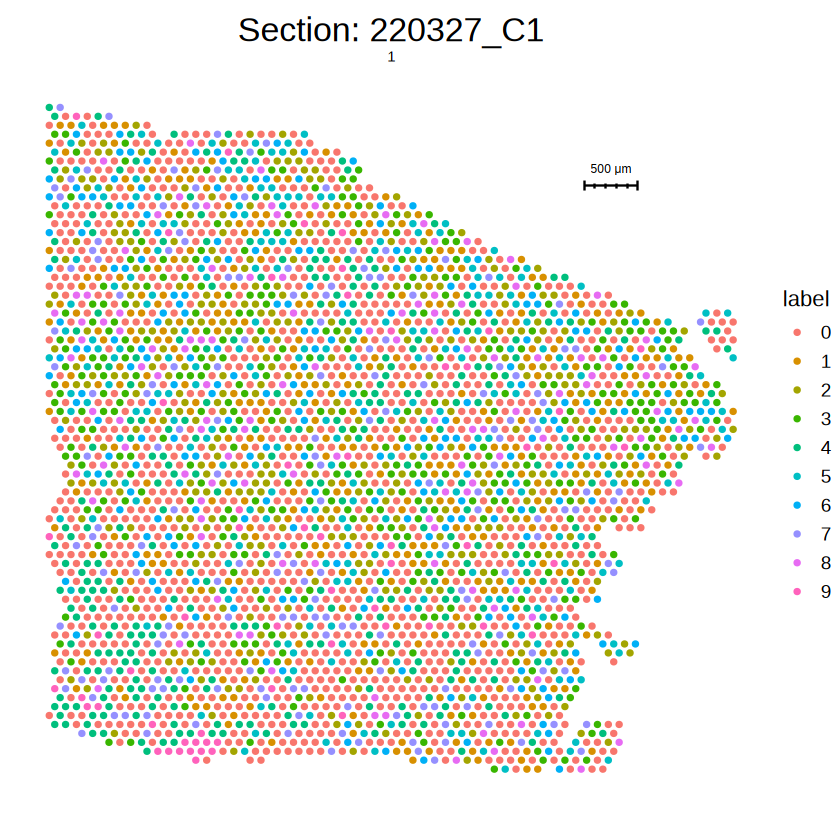

In [99]:
for (sec in unique(signac_selected$section)) {
    p <- ST.FeaturePlot(subset(signac_selected, section == sec), 
                        features = "seurat_clusters", 
                        # cols = colors_okate,
                        # cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"),
                        # cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#4f025a"),
                        pt.size = 1.8) +
         ggtitle(paste("Section:", sec)) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
#     plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
#     ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

## 4.2 - Plotting some regions accessibility

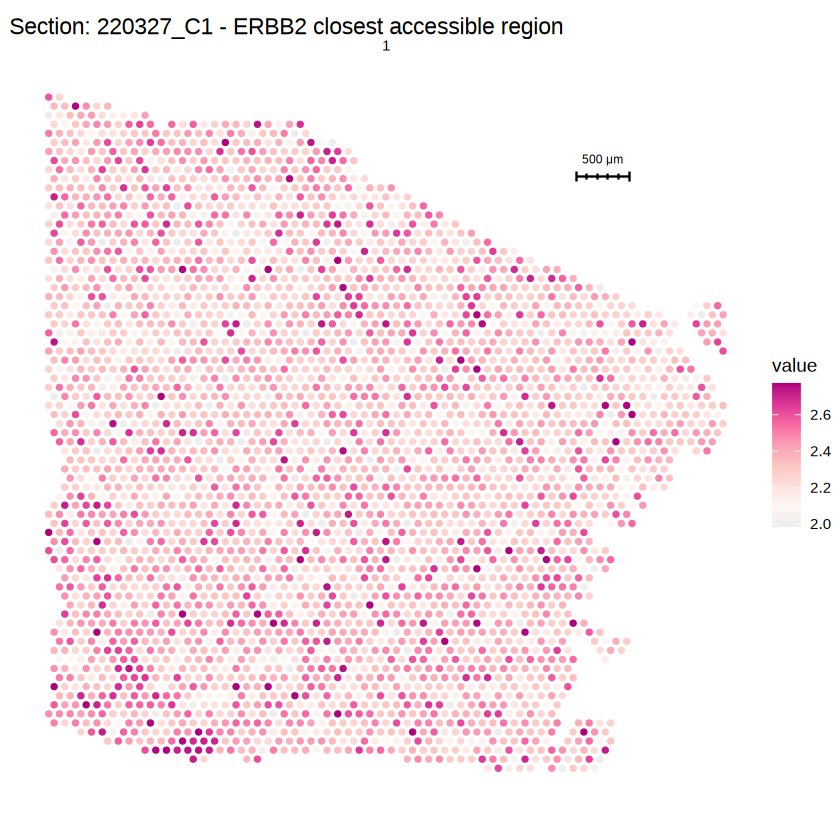

In [73]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)

ST.FeaturePlot(signac_selected, 
                # 'chr17-39699726-39700227', # closest to ERBB2
                'chr17-39723461-39723962', # from paper
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 closest accessible region"))

    # plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


---
# 5. - Gene activity

In [74]:
# signac_selected <- readRDS("output/sATAC_preprocessing/filtered_compared_brca_denoised_peaks.rds")

In [75]:
# calculate gene activity
DefaultAssay(signac_selected) <- "peaks"
# annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
# seqlevelsStyle(annotations) <- 'UCSC'
# Annotation(signac_selected) <- annotations
gene.activities <- GeneActivity(signac_selected)

Extracting gene coordinates

Warning message in SingleFeatureMatrix(fragment = fragments[[x]], features = features, :
"13 features are on seqnames not present in the fragment file. These will be removed."
Extracting reads overlapping genomic regions



In [76]:
# add the gene activity matrix to the Seurat object as a new assay and normalize it
#remove PCDH and UGT genes
gene.activities <- gene.activities[-grep("PCDH", rownames(gene.activities)),]
gene.activities <- gene.activities[-grep("UGT", rownames(gene.activities)),]
signac_selected[['RNA']] <- CreateAssayObject(counts = gene.activities)

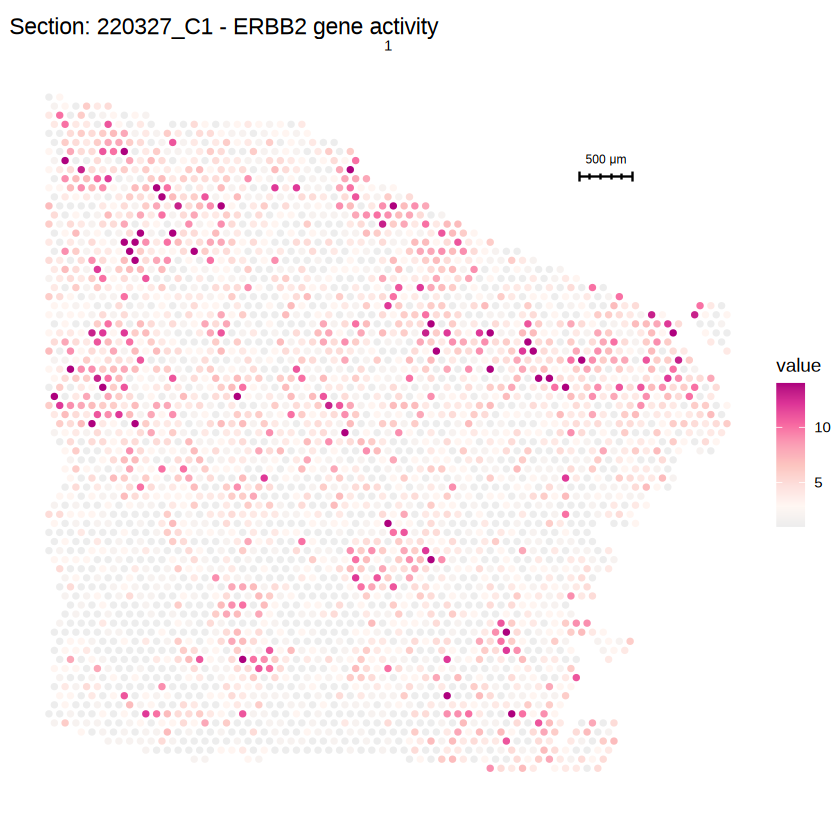

In [77]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)
DefaultAssay(signac_selected) <- "RNA"

ST.FeaturePlot(signac_selected, 
                'ERBB2', # from paper
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 gene activity"))

    # plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


In [78]:
write.csv(signac_selected@assays$RNA@counts, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca2.csv"))

In [80]:
# saveRDS(signac_selected, "output/sATAC_preprocessing/SESSION_WHERE_IT_WORKS.rds")
saveRDS(signac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "3_selected_", SELECTED_sATAC_SAMPLE,"_compared_brca_denoised_peaks.rds"))

## 5.1 - DCA for gene activity
Run DCA on terminal
```sh
nohup dca output/sATAC_preprocessing/gene_activity_selected_<SAMPLE_NAME>_brca.csv output/sATAC_preprocessing/dca_gene_activity_selected_<SAMPLE_NAME>_brca --threads 6 --saveweights > nohup_for_<SAMPLE_NAME>_dca_gene_activity.out &
```

In [81]:
signac_selected

An object of class Seurat 
447697 features across 3538 samples within 3 assays 
Active assay: RNA (19522 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: peaks, dca
 2 dimensional reductions calculated: lsi, umap

In [83]:
# gene activity
# signac_selected[["dca"]] <- NULL
mtx <- read.table(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "dca_gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca/mean.tsv"))
colnames(mtx) <- gsub("\\.", "-", colnames(mtx))

In [84]:
DefaultAssay(signac_selected) <- "RNA"
signac_selected <- subset(signac_selected, cells = colnames(mtx))

# add denoised matrix to object
signac_selected[["RNA_dca"]] <- CreateAssayObject(counts = as.matrix(mtx))
rm(mtx)

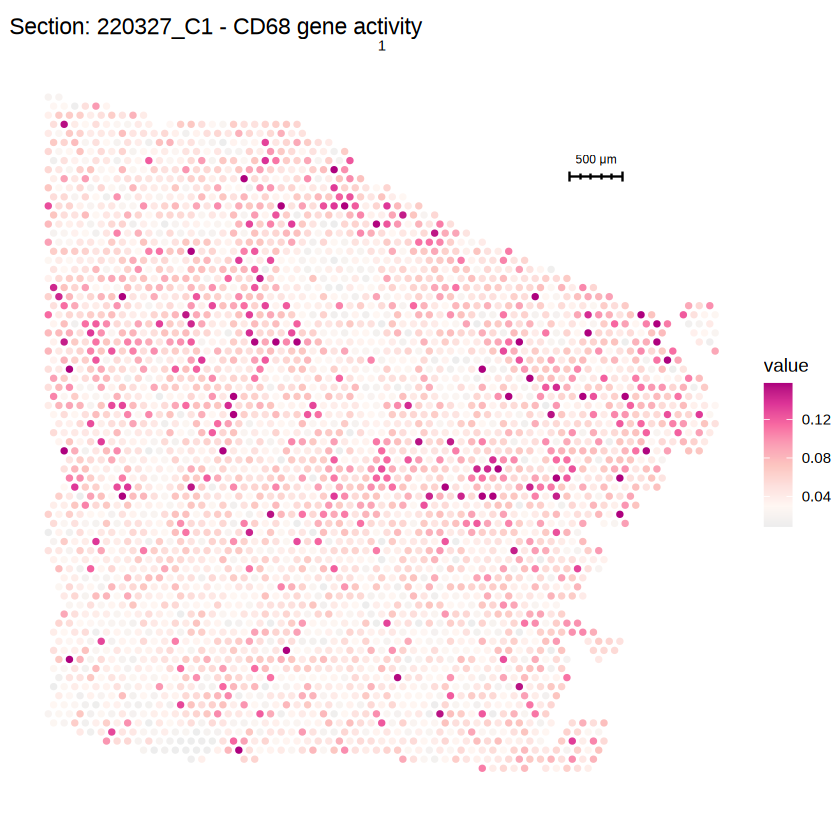

In [85]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)
DefaultAssay(signac_selected) <- "RNA_dca"

ST.FeaturePlot(signac_selected, 
                'CD68', # from paper
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- CD68 gene activity"))

    # plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


In [ ]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)
DefaultAssay(signac_selected) <- "dca"

ST.FeaturePlot(signac_selected, 
                'chr1-22652746-22653247', # from paper
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 gene activity"))

    # plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)

ERROR: Error in match.arg(arg = value, choices = Assays(object = object)): 'arg' should be one of "peaks", "dca", "RNA", "RNA_dca"


In [87]:
saveRDS(signac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "4_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca_denoised_RNA2.rds"))